In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# Load the German Credit dataset from OpenML
creditg = fetch_openml(name='credit-g', version=1, as_frame=True)
dataset = creditg.frame

# Check the shape and first few rows
print("Dataset shape:", dataset.shape)
print("\nFirst 5 rows:")
print(dataset.head())
print("\nColumn names:")
print(dataset.columns.tolist())


Dataset shape: (1000, 21)

First 5 rows:
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment     personal_status other_parties  ...  \
0                       4         male single          none  ...   
1                      

In [ ]:
# Check data types and basic statistics
print("Data types:")
print(dataset.dtypes)
print("\nBasic statistics for numeric columns:")
print(dataset.describe())

# Check class distribution
print("\nClass distribution:")
print(dataset['class'].value_counts())
print("\nClass distribution (%):")
print(dataset['class'].value_counts(normalize=True).round(2) * 100)

# Check for missing values
print("\nMissing values per column:")
print(dataset.isnull().sum())


Data types:
checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
class                     category
dtype: object

Basic statistics for numeric columns:
          duration  credit_amount  installment_commitment  residence_since  \
count  1000.000000    1000.000000             1000.000000      1000.000000   
mean     20.903000    3271.258000           

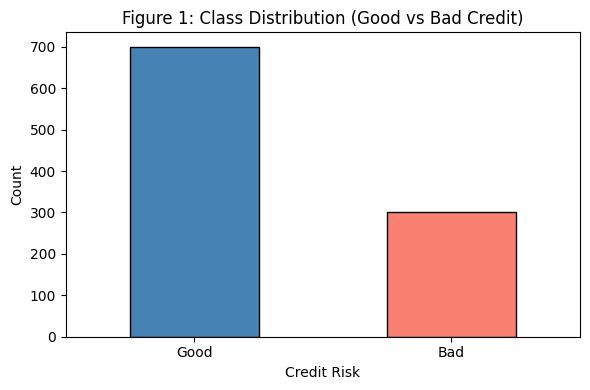

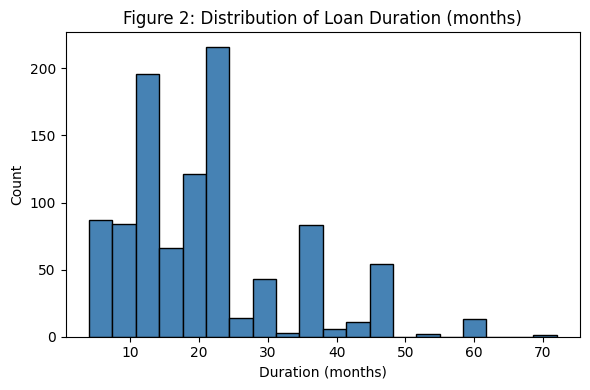

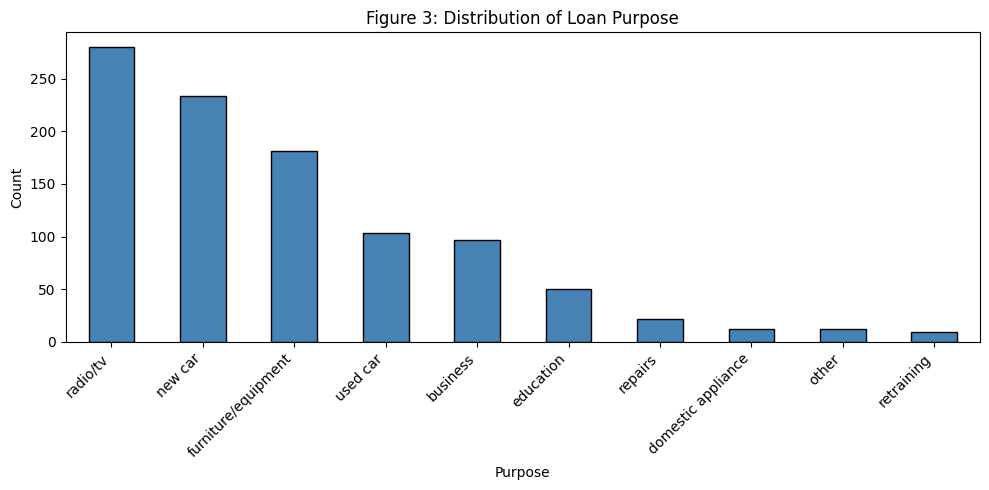

In [ ]:
# Figure 1: Class distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
dataset['class'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')
ax.set_title('Figure 1: Class Distribution (Good vs Bad Credit)')
ax.set_xlabel('Credit Risk')
ax.set_ylabel('Count')
ax.set_xticklabels(['Good', 'Bad'], rotation=0)
plt.tight_layout()
plt.show()

# Figure 2: Distribution of loan duration
fig, ax = plt.subplots(figsize=(6, 4))
dataset['duration'].plot(kind='hist', ax=ax, bins=20, color='steelblue', edgecolor='black')
ax.set_title('Figure 2: Distribution of Loan Duration (months)')
ax.set_xlabel('Duration (months)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Figure 3: Distribution of loan purpose
fig, ax = plt.subplots(figsize=(10, 5))
dataset['purpose'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Figure 3: Distribution of Loan Purpose')
ax.set_xlabel('Purpose')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Drop any rows with missing values
dataset = creditg.frame.dropna()
print("Rows after dropna:", dataset.shape[0])

# Define categorical and numeric input columns
categorical_cols = ['checking_status', 'credit_history', 'purpose', 'savings_status',
                    'employment', 'personal_status', 'other_parties',
                    'property_magnitude', 'other_payment_plans', 'housing',
                    'job', 'own_telephone', 'foreign_worker']

numeric_cols = ['duration', 'credit_amount', 'installment_commitment',
                'residence_since', 'age', 'existing_credits', 'num_dependents']

# Apply OneHotEncoder to categorical columns
# Each categorical column gets expanded into binary (0/1) columns
for col in categorical_cols:
    oe = OneHotEncoder(sparse_output=False)
    oe_results = oe.fit_transform(dataset[[col]])
    encoded_df = pd.DataFrame(oe_results,
                              columns=[f"{col}_{c}" for c in oe.categories_[0]],
                              index=dataset.index)
    dataset = dataset.join(encoded_df)

# Scale numeric columns using StandardScaler
# This puts all numeric features on the same scale so no single variable dominates
scaler = StandardScaler()
dataset[numeric_cols] = scaler.fit_transform(dataset[numeric_cols])

# Encode the target variable: 'bad' -> 0, 'good' -> 1
le = LabelEncoder()
y = le.fit_transform(dataset['class'])
print("Target classes:", le.classes_)
print("Encoded values (first 10):", y[:10])

# Build final feature matrix using scaled numeric + one-hot encoded columns
ohe_cols = [col for col in dataset.columns if any(col.startswith(c + '_') for c in categorical_cols)]
X = dataset[numeric_cols + ohe_cols]
print("\nFinal feature matrix shape:", X.shape)
print("Numeric features:", len(numeric_cols))
print("One-hot encoded features:", len(ohe_cols))


Rows after dropna: 1000
Target classes: ['bad' 'good']
Encoded values (first 10): [1 0 1 1 0 1 1 1 1 0]

Final feature matrix shape: (1000, 61)
Numeric features: 7
One-hot encoded features: 54


In [ ]:
# Split data into 70% training and 30% testing
# stratify=y ensures the 70/30 class imbalance is preserved in both splits
# random_state=42 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())
print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())


Training set size: (700, 61)
Testing set size: (300, 61)

Training class distribution:
1    490
0    210
Name: count, dtype: int64

Testing class distribution:
1    210
0     90
Name: count, dtype: int64


In [ ]:
# Model 1: Two hidden layers with 50 neurons each, ReLU activation
mlp1 = MLPClassifier(hidden_layer_sizes=(50, 50),
                     activation='relu',
                     solver='adam',
                     max_iter=500,
                     random_state=42)

mlp1.fit(X_train, y_train)

# Predictions on both train and test sets
y_train_pred1 = mlp1.predict(X_train)
y_test_pred1 = mlp1.predict(X_test)

# Training results
print("\nTraining Results:")
print(confusion_matrix(y_train, y_train_pred1))
print(classification_report(y_train, y_train_pred1, target_names=['bad', 'good']))

# Testing results
print("Testing Results:")
print(confusion_matrix(y_test, y_test_pred1))
print(classification_report(y_test, y_test_pred1, target_names=['bad', 'good']))



Training Results:
[[210   0]
 [  0 490]]
              precision    recall  f1-score   support

         bad       1.00      1.00      1.00       210
        good       1.00      1.00      1.00       490

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

Testing Results:
[[ 41  49]
 [ 43 167]]
              precision    recall  f1-score   support

         bad       0.49      0.46      0.47        90
        good       0.77      0.80      0.78       210

    accuracy                           0.69       300
   macro avg       0.63      0.63      0.63       300
weighted avg       0.69      0.69      0.69       300



In [ ]:
# Model 2: Three hidden layers with decreasing neurons, ReLU activation
mlp2 = MLPClassifier(hidden_layer_sizes=(100, 50, 25),
                     activation='relu',
                     solver='adam',
                     max_iter=500,
                     random_state=42)

mlp2.fit(X_train, y_train)

# Predictions on both train and test sets
y_train_pred2 = mlp2.predict(X_train)
y_test_pred2 = mlp2.predict(X_test)

# Training results
print("\nTraining Results:")
print(confusion_matrix(y_train, y_train_pred2))
print(classification_report(y_train, y_train_pred2, target_names=['bad', 'good']))

# Testing results
print("Testing Results:")
print(confusion_matrix(y_test, y_test_pred2))
print(classification_report(y_test, y_test_pred2, target_names=['bad', 'good']))



Training Results:
[[210   0]
 [  0 490]]
              precision    recall  f1-score   support

         bad       1.00      1.00      1.00       210
        good       1.00      1.00      1.00       490

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

Testing Results:
[[ 45  45]
 [ 38 172]]
              precision    recall  f1-score   support

         bad       0.54      0.50      0.52        90
        good       0.79      0.82      0.81       210

    accuracy                           0.72       300
   macro avg       0.67      0.66      0.66       300
weighted avg       0.72      0.72      0.72       300



In [ ]:
# Model 3: Same architecture as Model 2 but with tanh activation
mlp3 = MLPClassifier(hidden_layer_sizes=(100, 50, 25),
                     activation='tanh',
                     solver='adam',
                     max_iter=500,
                     random_state=42)

mlp3.fit(X_train, y_train)

# Predictions on both train and test sets
y_train_pred3 = mlp3.predict(X_train)
y_test_pred3 = mlp3.predict(X_test)

# Training results
print("\nTraining Results:")
print(confusion_matrix(y_train, y_train_pred3))
print(classification_report(y_train, y_train_pred3, target_names=['bad', 'good']))

# Testing results
print("Testing Results:")
print(confusion_matrix(y_test, y_test_pred3))
print(classification_report(y_test, y_test_pred3, target_names=['bad', 'good']))



Training Results:
[[210   0]
 [  0 490]]
              precision    recall  f1-score   support

         bad       1.00      1.00      1.00       210
        good       1.00      1.00      1.00       490

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

Testing Results:
[[ 43  47]
 [ 39 171]]
              precision    recall  f1-score   support

         bad       0.52      0.48      0.50        90
        good       0.78      0.81      0.80       210

    accuracy                           0.71       300
   macro avg       0.65      0.65      0.65       300
weighted avg       0.71      0.71      0.71       300



In [ ]:
# Summary comparison of all three models on test set
from sklearn.metrics import accuracy_score

models = ['Model 1: (50,50) relu',
          'Model 2: (100,50,25) relu',
          'Model 3: (100,50,25) tanh']

test_preds = [y_test_pred1, y_test_pred2, y_test_pred3]

print(f"\n{'Model':<30} {'Test Accuracy':>15} {'Bad Recall':>12} {'Good Recall':>12}")
print("-" * 72)

for model_name, pred in zip(models, test_preds):
    acc = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred,
                                   target_names=['bad', 'good'],
                                   output_dict=True)
    bad_recall = report['bad']['recall']
    good_recall = report['good']['recall']
    print(f"{model_name:<30} {acc:>15.2f} {bad_recall:>12.2f} {good_recall:>12.2f}")

print("\nBest model by test accuracy: Model 2 (100,50,25) relu")
print("Note: All models show 100% training accuracy vs ~70% test accuracy,")
print("indicating overfitting. Model 2 shows the best generalization.")


Model                            Test Accuracy   Bad Recall  Good Recall
------------------------------------------------------------------------
Model 1: (50,50) relu                     0.69         0.46         0.80
Model 2: (100,50,25) relu                 0.72         0.50         0.82
Model 3: (100,50,25) tanh                 0.71         0.48         0.81

Best model by test accuracy: Model 2 (100,50,25) relu
Note: All models show 100% training accuracy vs ~70% test accuracy,
indicating overfitting. Model 2 shows the best generalization.


In [ ]:
# Confusion matrix for Model 2 - best performing model
print("Confusion Matrix - Model 2: (100,50,25) relu")
print(confusion_matrix(y_test, y_test_pred2))
print("\nRows = Actual class (bad=0, good=1)")
print("Columns = Predicted class (bad=0, good=1)")

Confusion Matrix - Model 2: (100,50,25) relu
[[ 45  45]
 [ 38 172]]

Rows = Actual class (bad=0, good=1)
Columns = Predicted class (bad=0, good=1)
